# 1. Load Dataset

We are using a dataset from Hugging Face for phishing emails: https://huggingface.co/datasets/zefang-liu/phishing-email-dataset/viewer

First, we are importing the dataset directly:

In [ ]:
! pip install -q datasets huggingface_hub

In [ ]:
from datasets import load_dataset

dataset = load_dataset("zefang-liu/phishing-email-dataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/616 [00:00<?, ?B/s]

Phishing_Email.csv:   0%|          | 0.00/52.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18650 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd

df = pd.DataFrame(dataset['train'])
df.sample(5, random_state=42)

,Unnamed: 0,Email Text,Email Type
14469,14470,"Once upon a time, Harri wrote :> Title page ha...",Safe Email
3014,3014,new books : generative studies we would like t...,Safe Email
16941,16942,new book : japanese linguistics japanese lingu...,Safe Email
14344,14345,renewal notice for your domain name ( s ) dear...,Safe Email
8097,8098,hot stock tip your broker won ' t share now th...,Phishing Email


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB
None


There are three columns:
* `Unnamed: 0`: row column; integer
* `Email Text`: email data; object
* `Email Type`: email classification (phishing or safe); object
    * Phishing emails represent emails that were sent with malicious intent of obtaining personal information.
    * Safe emails represent legitimate emails.


# 2. Exploratory Data Analysis

"Verify **distribution overlap** between classes: compare email length, vocabulary, repeated phrases, domains, and metadata artifacts. If phishing and safe sets come from very different sources, models may learn shortcuts instead of phishing semantics."


### Class Distribution

Total: 18650
Non-phishing: 11322 -- 60.71%
Phishing: 7328 -- 39.29%


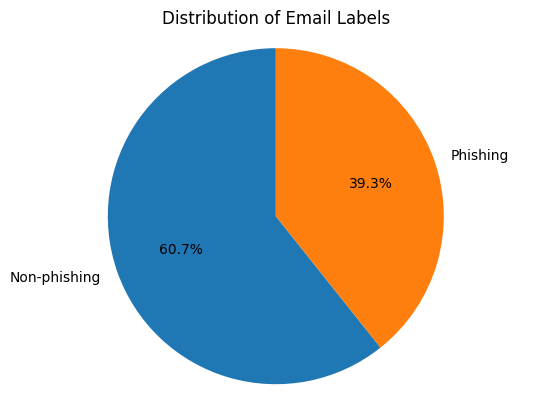

In [ ]:
import matplotlib.pyplot as plt

# check distribution
total = len(df)
non_phishing_count = df["Email Type"].value_counts()["Safe Email"]
phishing_count = df["Email Type"].value_counts()["Phishing Email"]

print(f"Total: {total}")
print(f"Non-phishing: {non_phishing_count} -- {non_phishing_count / total * 100:.2f}%")
print(f"Phishing: {phishing_count} -- {phishing_count / total * 100:.2f}%")

labels = ["Non-phishing", "Phishing"]
sizes = [non_phishing_count, phishing_count]

plt.figure()
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Email Labels")
plt.axis('equal')
plt.show()

We have about 63% of real emails and 37% of phishing emails in our dataset. The split is not near 50:50, and although the discrepancy isn't too much, we still need to be careful that our models would tend to classify emails as phishing, and other evaluation metrics aside from accuracy should be used to better evaluate model performances.

### Email Length

In [ ]:
df["char_count"] = df["Email Text"].astype(str).apply(len)
df["word_count"] = df["Email Text"].astype(str).apply(lambda x: len(x.split()))

print(df.groupby("Email Type")[["char_count", "word_count"]].describe())

               char_count                                                 \
                    count         mean            std  min    25%    50%   
Email Type                                                                 
Phishing Email     7328.0  1610.409389    3349.372587  1.0  353.0  731.0   
Safe Email        11322.0  3493.008391  160168.024661  5.0  444.0  994.5   

                                    word_count                                 \
                    75%         max      count        mean           std  min   
Email Type                                                                      
Phishing Email  1566.25    129635.0     7328.0  301.191184    569.722382  0.0   
Safe Email      2029.75  17036692.0    11322.0  685.870253  33160.236982  1.0   

                                               
                 25%    50%    75%        max  
Email Type                                     
Phishing Email  68.0  136.0  290.0    11625.0  
Safe Email      79.0 

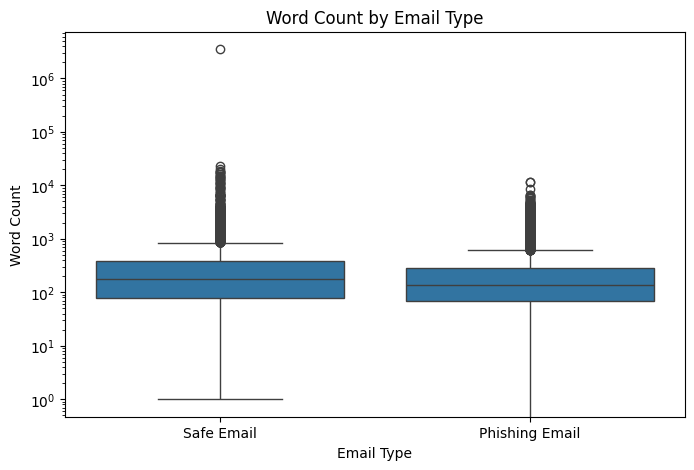

In [ ]:
import seaborn as sns

# visualize
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Email Type", y="word_count")
plt.yscale("log")
plt.title("Word Count by Email Type")
plt.ylabel("Word Count")
plt.show()

### Vocabulary Overlap


In [ ]:
from collections import Counter
import re

def tokenize_simple(text):
    return re.findall(r"\b\w+\b", str(text).lower())

phish_tokens = []
safe_tokens = []

phish_texts = df[df["Email Type"] == "Phishing Email"]["Email Text"]
safe_texts = df[df["Email Type"] == "Safe Email"]["Email Text"]

for text in phish_texts:
    phish_tokens.extend(tokenize_simple(text))

for text in safe_texts:
    safe_tokens.extend(tokenize_simple(text))

phish_counter = Counter(phish_tokens)
safe_counter = Counter(safe_tokens)

phish_top_100 = set(word for word, _ in phish_counter.most_common(100))
safe_top_100 = set(word for word, _ in safe_counter.most_common(100))

overlap = phish_top_100 & safe_top_100
jaccard = len(overlap) / len(phish_top_100 | safe_top_100)

print("Top-100 overlap count:", len(overlap))
print("Top-100 Jaccard overlap:", jaccard)

overlap_sorted = sorted(list(overlap))
print(overlap_sorted)

Top-100 overlap count: 78
Top-100 Jaccard overlap: 0.639344262295082
['0', '00', '1', '10', '2', '20', '3', '4', '5', '_', 'a', 'about', 'all', 'an', 'and', 'any', 'are', 'as', 'at', 'be', 'been', 'but', 'by', 'can', 'com', 'do', 'e', 'email', 'for', 'from', 'has', 'have', 'how', 'http', 'i', 'if', 'in', 'information', 'is', 'it', 'like', 'list', 'mail', 'may', 'me', 'more', 'my', 'new', 'no', 'not', 'of', 'on', 'one', 'only', 'or', 'our', 'out', 'please', 's', 'so', 't', 'that', 'the', 'these', 'they', 'this', 'time', 'to', 'up', 'was', 'we', 'what', 'which', 'will', 'with', 'www', 'you', 'your']


These overlapping words are mainly stopwords or redundant words that don't really have significant semantic meanings, like internet/email related words (e.g., "http", "com", "email", etc.).

Trying filtering out these words and recounting overlaps:

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_junk = {
    "http", "www", "com", "mail", "email", "e"
}

def tokenize_overlap(text):
    tokens = re.findall(r"\b\w+\b", str(text).lower())
    tokens = [
        tok for tok in tokens
        if tok not in ENGLISH_STOP_WORDS
        and tok not in custom_junk
        and len(tok) > 1
        and not tok.isdigit()
    ]
    return tokens

phish_tokens = []
safe_tokens = []

for text in phish_texts:
    phish_tokens.extend(tokenize_overlap(text))

for text in safe_texts:
    safe_tokens.extend(tokenize_overlap(text))

phish_counter = Counter(phish_tokens)
safe_counter = Counter(safe_tokens)

phish_top_100 = set(word for word, _ in phish_counter.most_common(100))
safe_top_100 = set(word for word, _ in safe_counter.most_common(100))

union = phish_top_100 | safe_top_100
overlap = phish_top_100 & safe_top_100
jaccard = len(overlap) / len(union) if len(union) > 0 else 0

print("Top-100 overlap count:", len(overlap))
print("Top-100 Jaccard overlap:", jaccard)
print("Overlap words:", sorted(list(overlap)))

Top-100 overlap count: 39
Top-100 Jaccard overlap: 0.2422360248447205
Overlap words: ['address', 'available', 'business', 'company', 'contact', 'day', 'does', 'fax', 'free', 'good', 'information', 'just', 'know', 'like', 'list', 'make', 'message', 'money', 'need', 'net', 'new', 'number', 'order', 'people', 'phone', 'program', 'report', 'send', 'site', 'software', 'subject', 'time', 'use', 'want', 'way', 'web', 'work', 'world', 'year']


### Repeated Phrases



In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(texts, ngram_range=(2,3), top_k=20):
    vec = CountVectorizer(lowercase=True, stop_words="english", ngram_range=ngram_range)
    X = vec.fit_transform(texts.astype(str))
    counts = X.sum(axis=0).A1
    terms = vec.get_feature_names_out()
    ranked = sorted(zip(terms, counts), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]

phishing_top = top_ngrams(phish_texts)
safe_top = top_ngrams(safe_texts)

phishing_df = pd.DataFrame(phishing_top, columns=["Phrase", "Count"])
safe_df = pd.DataFrame(safe_top, columns=["Phrase", "Count"])



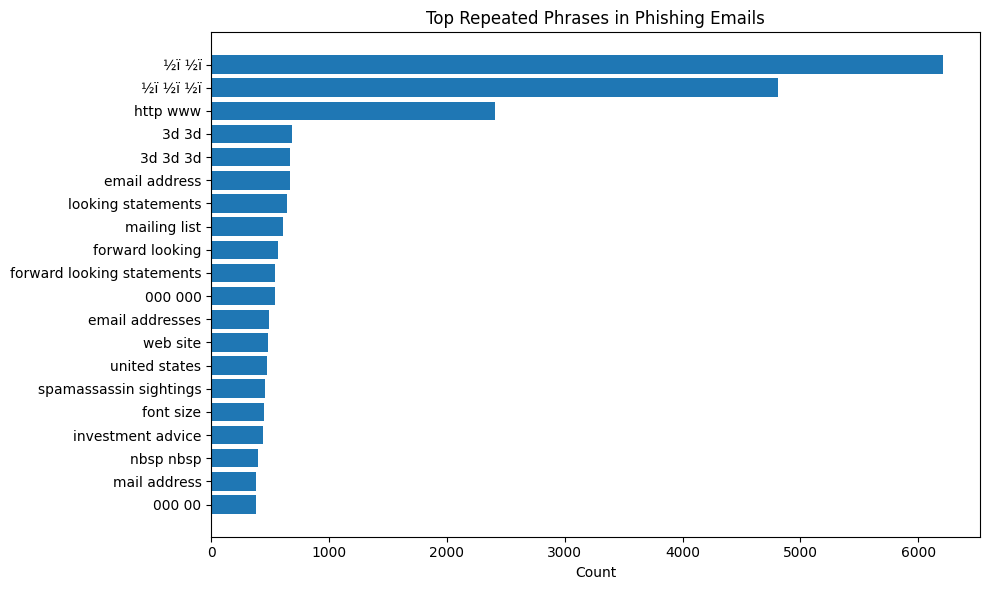

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(phishing_df["Phrase"][::-1], phishing_df["Count"][::-1])
plt.xlabel("Count")
plt.title("Top Repeated Phrases in Phishing Emails")
plt.tight_layout()
plt.show()

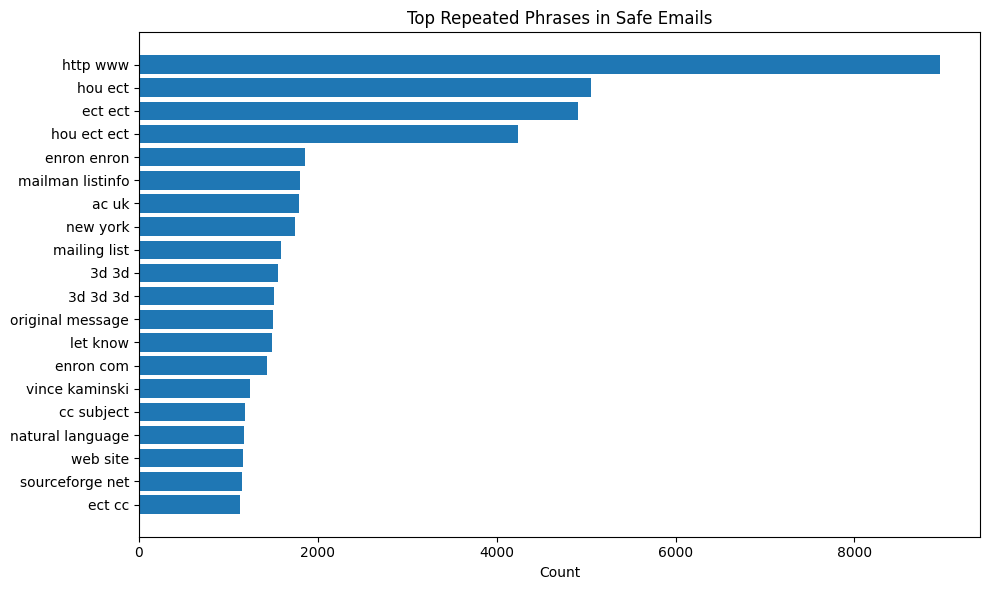

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(safe_df["Phrase"][::-1], safe_df["Count"][::-1])
plt.xlabel("Count")
plt.title("Top Repeated Phrases in Safe Emails")
plt.tight_layout()
plt.show()

# 3. Feature Engineering (for TF-IDF)
We're going to investigate what features distinguish phishing emails from safe emails. The followings are considered:
* phishing keywords
* capitalization ratio
* exclamation count
* URL count

<br>

### Keyword Dictionary
We begin by manually creating a dictionary of keywords that often signal phishing.
* Source:
    * https://expel.com/blog/top-phishing-keywords/
    * https://www.route-fifty.com/cybersecurity/2012/09/the-20-most-common-words-in-phishing-attacks/280956/






In [ ]:
import re
# phishing word dictionary

phishing_keywords = [
    "invoice", "new", "message", "required", "label",
    "file", "request", "action", "document", "verification",
    "copy", "statement", "financial", "notification",
    "transaction", "renewal"
]

def phishing_keyword_features(text):
    text = str(text).lower()

    # tokenize
    tokens = re.findall(r"\b\w+\b", text)

    # track total count of keywords and unique keywords
    keyword_count = sum(token in phishing_keywords for token in tokens)
    unique_keyword_count = len(set(token for token in tokens if token in phishing_keywords))

    # binary value
    has_phishing_keyword = 1 if keyword_count > 0 else 0

    return keyword_count, unique_keyword_count, has_phishing_keyword

### Capitalization Ratio

In [ ]:
def get_capitalization_ratio(text):
    text = str(text)

    letters = sum(1 for char in text if char.isalpha())
    if letters == 0:
        return 0

    capitalized_letter = sum(1 for char in text if char.isupper())
    return (capitalized_letter / letters) if letters > 0 else 0

### Exclamation Count

In [ ]:
def get_exclamation_count(text):
    text = str(text)
    return text.count("!")

### URL Count

In [ ]:
def get_url_count(text):
    text = str(text)
    return len(re.findall(r"http[s]?://\S+|www\.\S+", text))

### Wrapper function
This function applies all feature extraction functions to the input text data and returns a dictionary with the numeric counts.

In [ ]:
def feature_extraction(text):
    text = str(text)

    keyword_count, unique_keyword_count, has_phishing_keyword = phishing_keyword_features(text)
    capitalization_ratio = get_capitalization_ratio(text)
    exclamation_count = get_exclamation_count(text)
    url_count = get_url_count(text)

    return pd.Series({
        "total_phishing_keyword_count": keyword_count,
        "unique_phishing_keyword_count": unique_keyword_count,
        "has_phishing_keyword": has_phishing_keyword,
        "capitalization_ratio": capitalization_ratio,
        "exclamation_count": exclamation_count,
        "url_count": url_count
    })

# 4. Preprocessing & Splitting
This is a shared standardized preprocessing step applied to all models:
    

In [ ]:
df = df[["Email Text", "Email Type"]]
df.columns = ["text", "label"]
df.head()

,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [ ]:
df["label"] = df["label"].apply(lambda x: 1 if x == "Phishing Email" else 0)
df.head()

,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1


In [ ]:
import pandas as pd
import re
from collections import defaultdict

def clean_email_text(text):
    """Basic text cleaning for duplicate detection."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = re.sub(r"[^a-z0-9\s]", " ", text)      # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()      # normalize spaces
    return text

def further_clean(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"\S+@\S+", " <EMAIL> ", text)
    text = re.sub(r"\b\d+\b", " <NUM> ", text)
    text = re.sub(r"\b(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)\b", " <DATE> ", text)
    text = re.sub(r"\b(account|invoice|order|id|number)\s*\w*", r"\1 <ID>", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
df["text"] = df["text"].apply(clean_email_text)
df["text"] = df["text"].apply(further_clean)

df.head()


,text,label
0,re <NUM> <NUM> disc uniformitarianism re <NUM>...,0
1,the other side of galicismos galicismo is a sp...,0
2,re equistar deal tickets are you still availab...,0
3,hello i am your hot lil horny toy i am the one...,1
4,software at incredibly low prices <NUM> lower ...,1


In [ ]:
df = df.drop_duplicates()
df = df.dropna()
print(len(df))

17136


In [ ]:
df["text_length"] = df["text"].str.split().str.len()

df.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,10691.0,547.966327,24214.441023,0.0,76.5,163.0,324.5,2502955.0
1,6445.0,263.149263,495.822992,0.0,60.0,117.0,256.0,11751.0


In [ ]:
df = df[df["text_length"] <= 500]
df = df[df["text_length"] > 20]

df.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,8741.0,172.383137,119.145083,21.0,75.0,143.0,245.00,500.0
1,5306.0,142.676027,110.229270,21.0,62.0,107.0,186.75,500.0


In [ ]:
len(df)

14047

In [ ]:
from sklearn.model_selection import train_test_split

x = df["text"]
y = df["label"]

# split into train(80) and temp (20)
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y,
    random_state=3,
    test_size=0.2,
    stratify=y)

print(x_train.shape)
print(x_temp.shape)

(11237,)
(2810,)


In [ ]:
x_valid, x_test, y_valid, y_test = train_test_split(
    x_temp, y_temp,
    random_state=3,
    test_size=0.5,
    stratify=y_temp)

print(x_valid.shape)
print(x_test.shape)

(1405,)
(1405,)


### Data Leakage Check

In [ ]:
train_texts = set(x_train.astype(str))
valid_texts = set(x_valid.astype(str))
test_texts = set(x_test.astype(str))

train_valid_overlap = train_texts & valid_texts
train_test_overlap = train_texts & test_texts
valid_test_overlap = valid_texts & test_texts

print("Exact overlap: train-valid =", len(train_valid_overlap))
print("Exact overlap: train-test =", len(train_test_overlap))
print("Exact overlap: valid-test =", len(valid_test_overlap))

Exact overlap: train-valid = 0
Exact overlap: train-test = 0
Exact overlap: valid-test = 0


No exact emails overlapping across different sets.

In [ ]:
#average amount of tokens -> important for max_length parameter in tokenizer

texts = df["text"].to_list()
avg_word_num = []

for t in texts:
    words = t.split()
    avg_word_num.append(len(words))

print(sum(avg_word_num)/len(avg_word_num))
print(max(avg_word_num))

161.1618139104435
500


In [ ]:
import numpy as np

median_val = np.median(avg_word_num)
print(median_val)

127.0


In [ ]:
pd.Series(avg_word_num).describe()

,0
count,14047.000000
mean,161.161814
std,116.745863
min,21.000000
25%,69.000000
50%,127.000000
75%,225.000000
max,500.000000


We concluded that the length we should use for transfer learning models is 256 for transfer learning models. The text lengths must be positively skewed because the median text length has a value extremely lower than the average. Our chosen length allows our models to be computationally efficient, while also considering the nature of our texts in the dataset.

# 5. Modeling
We're comparing four different models:
1. [TF-IDF + Logistic Regression](https://colab.research.google.com/drive/18jiNTCDkQczXFgOJ56klRnA4492XF2TO?usp=sharing)
2. [BERT](https://colab.research.google.com/drive/11QMKmRtf1XKPOzkCmX6XRk4wc-qIPCib?usp=sharing)
3. [RoBERTa](https://drive.google.com/file/d/1k8LwIFKWqiIu-DhzjPYx070Ltdy0rEmC/view?usp=sharing)
4. [T5](https://drive.google.com/file/d/1uErlsdIc7EzCkFqvXQZtmAZH5qXBAr0O/view?usp=sharing)

### Load Models

In [ ]:
# tfidf + LR with features
import joblib

tfidf_lr = joblib.load("tfidf_lr_phishing.pkl")

tfidf = tfidf_lr["tfidf"]
scaler = tfidf_lr["scaler"]
lr = tfidf_lr["model"]


In [ ]:
# bert
!unzip fine_tuned_bert_phishing.zip

Archive:  fine_tuned_bert_phishing.zip
   creating: fine_tuned_bert_phishing/
  inflating: fine_tuned_bert_phishing/model.safetensors  
  inflating: fine_tuned_bert_phishing/tokenizer.json  
  inflating: fine_tuned_bert_phishing/config.json  
  inflating: fine_tuned_bert_phishing/tokenizer_config.json  


In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification

model_path = "./fine_tuned_bert_phishing"

bert_tokenizer = BertTokenizer.from_pretrained(model_path)
bert_model = BertForSequenceClassification.from_pretrained(model_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
!unzip /content/RoBERTa_phishing_model.zip

Archive:  /content/RoBERTa_phishing_model.zip
   creating: RoBERTa_phishing_model/
  inflating: __MACOSX/._RoBERTa_phishing_model  
  inflating: RoBERTa_phishing_model/model.safetensors  
  inflating: __MACOSX/RoBERTa_phishing_model/._model.safetensors  
  inflating: RoBERTa_phishing_model/tokenizer_config.json  
  inflating: __MACOSX/RoBERTa_phishing_model/._tokenizer_config.json  
  inflating: RoBERTa_phishing_model/config.json  
  inflating: __MACOSX/RoBERTa_phishing_model/._config.json  
  inflating: RoBERTa_phishing_model/tokenizer.json  
  inflating: __MACOSX/RoBERTa_phishing_model/._tokenizer.json  


In [ ]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification

model_path = "RoBERTa_phishing_model"

roberta_tokenizer = RobertaTokenizer.from_pretrained(model_path)
roberta_model = RobertaForSequenceClassification.from_pretrained(model_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# t5
!unzip t5_phishing_classifier.zip

Archive:  t5_phishing_classifier.zip
   creating: t5_phishing_classifier/
  inflating: t5_phishing_classifier/model.safetensors  
  inflating: t5_phishing_classifier/tokenizer.json  
  inflating: t5_phishing_classifier/config.json  
  inflating: t5_phishing_classifier/tokenizer_config.json  
  inflating: t5_phishing_classifier/generation_config.json  


In [ ]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

model_path = "./t5_phishing_classifier"

t5_tokenizer = T5Tokenizer.from_pretrained(model_path)
t5_model = T5ForConditionalGeneration.from_pretrained(model_path)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

# 6. Evaluating Models on Test Data

### TF-IDF + LR with Handcrafted Features

In [ ]:
# tfidf
x_test_tfidf = tfidf.transform(x_test)
x_test_features_clean = x_test.apply(feature_extraction)
x_test_features_scaled = scaler.transform(x_test_features_clean)

# combine tfidf and features
from scipy.sparse import hstack, csr_matrix
x_test_combined = hstack((x_test_tfidf, csr_matrix(x_test_features_scaled)))

# predict with LR
y_test_pred_tfidf = lr.predict(x_test_combined)
y_test_prob_tfidf = lr.predict_proba(x_test_combined)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_test_pred_tfidf))
print(classification_report(y_test, y_test_pred_tfidf))

Accuracy: 0.9850533807829182
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       875
           1       0.98      0.98      0.98       530

    accuracy                           0.99      1405
   macro avg       0.98      0.98      0.98      1405
weighted avg       0.99      0.99      0.99      1405



### BERT

In [ ]:
# tokenize test text
test_encodings = bert_tokenizer(
    x_test.tolist(),
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt"
)

In [ ]:
# move model to eval mode
bert_model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)

test_encodings = {k: v.to(device) for k, v in test_encodings.items()}

In [ ]:
import numpy as np

bert_model.eval()

all_logits = []
all_probs = []
batch_size = 32

with torch.no_grad():
    for i in range(0, len(test_encodings['input_ids']), batch_size):
        batch_input_ids = test_encodings['input_ids'][i:i+batch_size]
        batch_attention_mask = test_encodings['attention_mask'][i:i+batch_size]
        batch_token_type_ids = test_encodings['token_type_ids'][i:i+batch_size]

        batch_encodings = {
            'input_ids': batch_input_ids,
            'attention_mask': batch_attention_mask,
            'token_type_ids': batch_token_type_ids
        }

        outputs = bert_model(**batch_encodings)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

        all_logits.append(logits.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

# concatenate all batch results
logits_np = np.concatenate(all_logits, axis=0)
probs_np = np.concatenate(all_probs, axis=0)

# probabilities and labels
y_test_prob_bert = probs_np[:, 1]
y_test_pred_bert = np.argmax(logits_np, axis=1)


In [ ]:
# evaluate
print("Accuracy:", accuracy_score(y_test, y_test_pred_bert))
print(classification_report(y_test, y_test_pred_bert))

Accuracy: 0.993594306049822
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       875
           1       1.00      0.99      0.99       530

    accuracy                           0.99      1405
   macro avg       0.99      0.99      0.99      1405
weighted avg       0.99      0.99      0.99      1405



### RoBERTa

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
roberta_model.to(device)
roberta_model.eval()

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
# predict
batch_size = 16

roberta_preds = []
roberta_probs = []

x_test_list = x_test.tolist()

for i in range(0, len(x_test_list), batch_size):
    batch_texts = x_test_list[i:i+batch_size]

    batch_encodings = roberta_tokenizer(
        batch_texts,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    batch_encodings = {k: v.to(device) for k, v in batch_encodings.items()}

    with torch.no_grad():
        outputs = roberta_model(**batch_encodings)
        logits = outputs.logits

    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(logits, dim=1)

    roberta_preds.extend(preds.cpu().numpy())
    roberta_probs.extend(probs[:, 1].cpu().numpy())

In [ ]:
y_test_pred_roberta = np.array(roberta_preds)
y_test_prob_roberta = np.array(roberta_probs)

In [ ]:
# evaluate
print("Accuracy:", accuracy_score(y_test, y_test_pred_roberta))
print(classification_report(y_test, y_test_pred_roberta))

Accuracy: 0.9928825622775801
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       875
           1       1.00      0.98      0.99       530

    accuracy                           0.99      1405
   macro avg       0.99      0.99      0.99      1405
weighted avg       0.99      0.99      0.99      1405



### T5


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t5_model.to(device)
t5_model.eval()

T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=512, bias=False)
              (k): Linear(in_features=512, out_features=512, bias=False)
              (v): Linear(in_features=512, out_features=512, bias=False)
              (o): Linear(in_features=512, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 8)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=512, out_features=2048, bias=False)
              (wo): Linear(in_features=2048, out_features=512, bias=False)
              (dropout): Drop

In [ ]:
# test data
x_test_t5 = x_test.apply(lambda x: f"classify email: {x}")

In [ ]:
# tokenize
test_encodings = t5_tokenizer(
    x_test_t5.tolist(),
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt"
)

test_encodings = {k: v.to(device) for k, v in test_encodings.items()}

In [ ]:
# generate outputs
import torch
import numpy as np

all_generated_ids = []
batch_size = 32

with torch.no_grad():
    for i in range(0, test_encodings["input_ids"].size(0), batch_size):
        batch_input_ids = test_encodings["input_ids"][i : i + batch_size]
        batch_attention_mask = test_encodings["attention_mask"][i : i + batch_size]

        outputs = t5_model.generate(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask,
            max_length=5 # safe than 2
        )
        all_generated_ids.append(outputs.cpu())

# concatenate
generated_ids = torch.cat(all_generated_ids, dim=0)

# decode ids to text
decoded_outputs = t5_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

# 0 or 1 for classification
y_test_pred_t5 = np.array([int(output.strip()) if output.strip().isdigit() else -1 for output in decoded_outputs])

def map_output(output):
    output = output.strip().lower()

    if output == "safe":
        return 0
    elif output == "phishing":
        return 1
    else:
        return -1

y_test_pred_t5 = np.array([map_output(output) for output in decoded_outputs])

print("First 10 decoded outputs:", decoded_outputs[:10])
print("First 10 T5 predictions:", y_test_pred_t5[:10])

First 10 decoded outputs: ['safe', 'phishing', 'safe', 'safe', 'safe', 'phishing', 'safe', 'phishing', 'phishing', 'phishing']
First 10 T5 predictions: [0 1 0 0 0 1 0 1 1 1]


In [ ]:
# evaluate
print("Accuracy:", accuracy_score(y_test, y_test_pred_t5))
print(classification_report(y_test, y_test_pred_t5))

Accuracy: 0.9451957295373665
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       875
           1       0.98      0.88      0.92       530

    accuracy                           0.95      1405
   macro avg       0.95      0.93      0.94      1405
weighted avg       0.95      0.95      0.94      1405



# 7. Comparing Models: Confusion Matrices


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels = ["Safe", "Phishing"],
                yticklabels = ["Safe", "Phishing"])

    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

### TF-IDF + LR

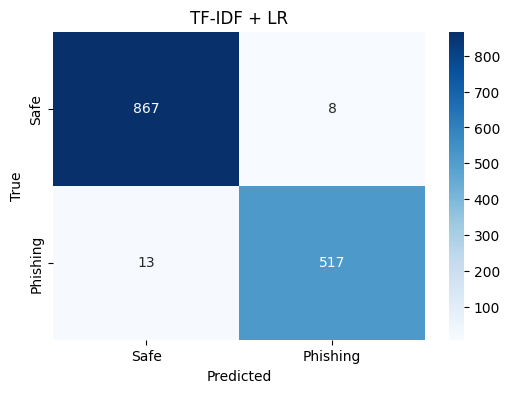

In [ ]:
plot_confusion_matrix(y_test, y_test_pred_tfidf, "TF-IDF + LR")

### BERT

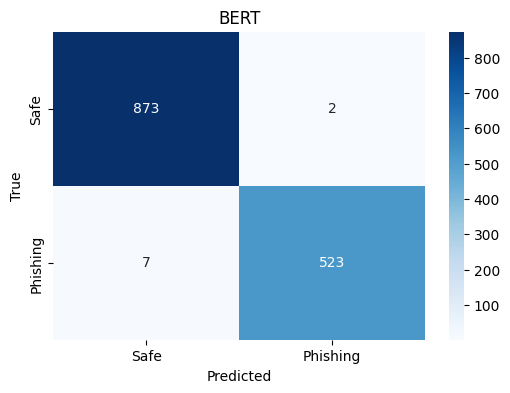

In [ ]:
plot_confusion_matrix(y_test, y_test_pred_bert, "BERT")

### RoBERTa

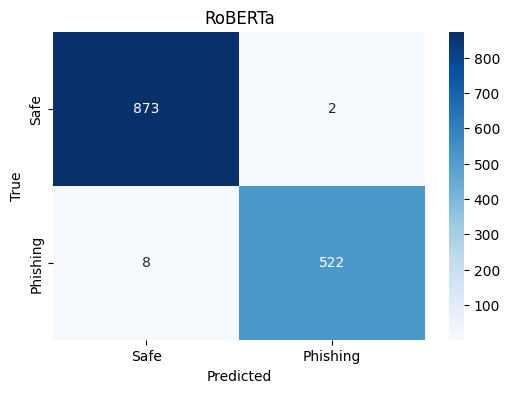

In [ ]:
plot_confusion_matrix(y_test, y_test_pred_roberta, "RoBERTa")

### T5

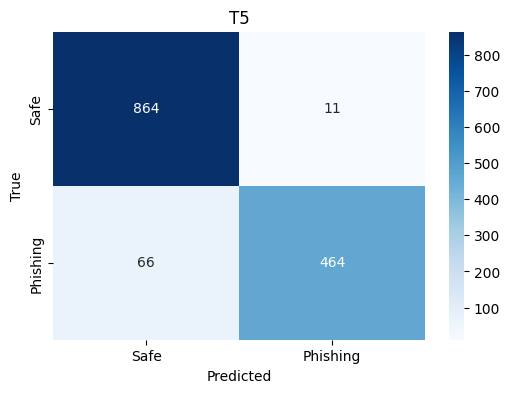

In [ ]:
plot_confusion_matrix(y_test, y_test_pred_t5, "T5")

# 8. Demo

In [ ]:
print("TFIDF:", 'tfidf' in globals())
print("LR:", 'lr' in globals())
print("BERT:", 'bert_model' in globals())
print("RoBERTa:", 'roberta_model' in globals())
print("T5:", 't5_model' in globals())

print("Cleaning:", 'clean_email_text' in globals())
print("Feature:", 'feature_extraction' in globals())

TFIDF: True
LR: True
BERT: True
RoBERTa: True
T5: True
Cleaning: True
Feature: True


In [ ]:
import numpy as np
import torch
from scipy.sparse import hstack, csr_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def predict_email(text, model_choice):
    text = str(text)

    # IMPORTANT: apply same cleaning as training
    text_clean = further_clean(clean_email_text(text))

    # ---------------- TF-IDF + LR ----------------
    if model_choice == "TF-IDF + LR":
        text_tfidf = tfidf.transform([text_clean])

        features = feature_extraction(text_clean).values.reshape(1, -1)
        features_scaled = scaler.transform(features)

        combined = hstack((text_tfidf, csr_matrix(features_scaled)))

        prob = lr.predict_proba(combined)[0][1]
        pred = lr.predict(combined)[0]

    # ---------------- BERT ----------------
    elif model_choice == "BERT":
        inputs = bert_tokenizer(
            text_clean,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256
        ).to(device)

        with torch.no_grad():
            outputs = bert_model(**inputs)
            probs = torch.softmax(outputs.logits, dim=1)

        prob = probs[0][1].item()
        pred = torch.argmax(probs, dim=1).item()

    # ---------------- RoBERTa ----------------
    elif model_choice == "RoBERTa":
        inputs = roberta_tokenizer(
            text_clean,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256
        ).to(device)

        with torch.no_grad():
            outputs = roberta_model(**inputs)
            probs = torch.softmax(outputs.logits, dim=1)

        prob = probs[0][1].item()
        pred = torch.argmax(probs, dim=1).item()

    # ---------------- T5 ----------------
    elif model_choice == "T5":
        input_text = f"classify email: {text_clean}"

        inputs = t5_tokenizer(
            input_text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256
        ).to(device)

        with torch.no_grad():
            outputs = t5_model.generate(**inputs, max_length=5)

        decoded = t5_tokenizer.decode(outputs[0], skip_special_tokens=True).lower()

        if "phishing" in decoded:
            pred = 1
            prob = 1.0
        else:
            pred = 0
            prob = 0.0

    label = "Phishing" if pred == 1 else "Safe"

    return label, f"{prob:.2%}"

In [ ]:
import gradio as gr

with gr.Blocks() as demo:
    gr.Markdown("# 📧 Phishing Email Detector")

    text_input = gr.Textbox(
        lines=8,
        placeholder="Paste an email here..."
    )

    model_choice = gr.Radio(
        ["TF-IDF + LR", "BERT", "RoBERTa", "T5"],
        value="BERT",
        label="Select Model"
    )

    run_btn = gr.Button("Analyze")

    prediction = gr.Textbox(label="Prediction")
    confidence = gr.Textbox(label="Phishing Probability")

    run_btn.click(
        fn=predict_email,
        inputs=[text_input, model_choice],
        outputs=[prediction, confidence]
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e39ffb5eed7f0aba2c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Unsafe examples:

Subject: URGENT: Verify Your Account Now

Dear Customer,

We detected unusual activity on your account. Your account will be suspended unless you verify your information immediately.

Click here to verify your account:
http://secure-login-update.com

Failure to act within 24 hours will result in permanent suspension.

Thank you,
Security Team

Subject: Invoice Attached - Action Required

Hello,

Please find your invoice attached. Payment is required immediately to avoid late fees.

You can complete your payment here:
http://payment-secure-portal.com

Let us know once completed.

Regards,
Billing Department

Subject: Meeting Tomorrow

Hi,

Just a reminder that we have our group meeting tomorrow at 3 PM in the library.

Let me know if you need anything beforehand.

Thanks!